# BERT Bias Classification - Source Domain Diagnosis (v5)

## Objective
Diagnose whether the BERT attention-based bias classifier is learning **bias signals** or **source/style artifacts** on the v5 dataset.

### Dataset: bias_sentences_v5.json (8922 entries)
This dataset is loaded from a single JSON file with an `entries` key:
- **`biased_corpus_only`** (3260 entries)
- **`gemini_only`** (2985 entries)
- **`gus_only`** (2708 entries)

### Diferenca vs v3 (9434)
O v3 carregava 3 CSVs separados e usava `hasbias` como label.
O v5 usa um unico JSON (`bias_sentences_v5.json`) com campo `has_bias` e 8922 entradas.

### Features
Uses the precomputed BERT attention feature matrix:
- **`attention_app/bias/extracted_features/feature_matrix_bert_v5.pkl`**
- 3238 numerical attention-derived features plus label metadata

### Methodology
- Pipeline: `VarianceThreshold(0.01) -> StandardScaler -> Classifier`
- Grouping: text-based groups to avoid leakage
- CV: `StratifiedGroupKFold(n_splits=5)`
- Tuning: `HalvingRandomSearchCV`

### Diagnostic Tests
1. **Leave-One-Source-Out (LOSO)**: train on 2 sources, test on the 3rd
2. **Source Classifier**: predict source from the same attention features
3. **Bias Classifier**: full train/test evaluation with group-based split
4. **Residualization**: regress out source signal, then re-run diagnosis
5. **Error Analysis**: compare errors by source and text type

## 1. Setup and Imports

In [54]:
import subprocess
import sys

try:
    import xgboost  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

In [55]:
import json
import os
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    HalvingRandomSearchCV,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier


def find_root(start: Path, repo_name: str = 'attention-atlas') -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    return start


# In VS Code Jupyter, __vsc_ipynb_file__ holds the notebook path
_nb_file = Path(globals().get('__vsc_ipynb_file__', '') or '')
if _nb_file.exists():
    root_dir = find_root(_nb_file.parent)
else:
    root_dir = find_root(Path.cwd())
notebook_dir = root_dir / 'dataset' / 'v2'

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Root dir: {root_dir}')
print(f'Notebook dir: {notebook_dir}')

Root dir: C:\Users\anoca\Documents\GitHub\attention-atlas
Notebook dir: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\v2


## 2. Load v5 Dataset from JSON and Validate

Load the dataset from `bias_sentences_v5.json`.
The JSON has a top-level `entries` key with fields: `id, type, text, has_bias, bias_type, bias_description, source, role, original_id, pair_id, topic, sentence_id, edit_spans`.

In [56]:
dataset_path = notebook_dir / 'bias_sentences_v6.json'
with open(dataset_path, encoding='utf-8') as f:
    raw = json.load(f)

df_sentences = pd.DataFrame(raw['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)

# Canonical source names
SOURCE_CANONICAL = {
    'biased_corpus_only': 'biased-corpus',
    'biased_corpus_v2': 'biased-corpus',
    'gemini_only': 'gemini',
    'gemini_only_v2': 'gemini',
    'gus_only': 'gus-dataset',
    'gus_only_v2': 'gus-dataset',
}
df_sentences['source_canonical'] = df_sentences['source'].map(SOURCE_CANONICAL).fillna(df_sentences['source'])

print(f'V5 dataset: {len(df_sentences)} entries')
print(f'Unique texts: {df_sentences["text"].nunique()} / {len(df_sentences)}')
print(f'Label distribution: {df_sentences["label"].value_counts().sort_index().to_dict()}')
print(f'Sources (raw): {df_sentences["source"].value_counts().to_dict()}')
print(f'Sources (canonical): {df_sentences["source_canonical"].value_counts().to_dict()}')

V5 dataset: 10416 entries
Unique texts: 10416 / 10416
Label distribution: {0: 5082, 1: 5334}
Sources (raw): {'gemini_only': 4488, 'biased_corpus_only': 3258, 'gus_only': 2670}
Sources (canonical): {'gemini': 4488, 'biased-corpus': 3258, 'gus-dataset': 2670}


In [57]:
# Cross-source text overlap
source_groups = df_sentences.groupby('source')['text'].apply(set)
source_names = list(source_groups.index)

print('Cross-source text overlap (should be 0):')
for i in range(len(source_names)):
    for j in range(i + 1, len(source_names)):
        overlap = source_groups[source_names[i]] & source_groups[source_names[j]]
        print(f'  {source_names[i]} vs {source_names[j]}: {len(overlap)}')

print('\nBias by source:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['label'], margins=True))

print('\nRole distribution:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['role'], margins=True))

Cross-source text overlap (should be 0):
  biased_corpus_only vs gemini_only: 0
  biased_corpus_only vs gus_only: 0
  gemini_only vs gus_only: 0

Bias by source:
label                0     1    All
source_canonical                   
biased-corpus     1337  1921   3258
gemini            2302  2186   4488
gus-dataset       1443  1227   2670
All               5082  5334  10416

Role distribution:
role              counterfactual  original  unpaired    All
source_canonical                                           
biased-corpus                967       969      1322   3258
gemini                      2181      2181       126   4488
gus-dataset                  753       751      1166   2670
All                         3901      3901      2614  10416


## 3. Load Feature Matrix

Load the precomputed BERT feature matrix for the v5 dataset and align it with the metadata.

**Nota:** se o ficheiro `feature_matrix_bert_v5.pkl` ainda nao existe, e necessario correr primeiro o script de extracao:
```bash
python dataset/v2/extract_bert_features_v2.py --dataset-path dataset/v2/bias_sentences_v5.json --output-path attention_app/bias/extracted_features/feature_matrix_bert_v5.pkl
```

In [58]:
features_path = root_dir / 'attention_app' / 'bias' / 'extracted_features' / 'feature_matrix_bert_v6.pkl'
if not features_path.exists():
    raise FileNotFoundError(
        f'Feature matrix not found: {features_path}\n'
        'Run the extraction script first:\n'
        '  python dataset/v2/extract_bert_features_v2.py '
        '--dataset-path dataset/v2/bias_sentences_v5.json '
        '--output-path attention_app/bias/extracted_features/feature_matrix_bert_v5.pkl'
    )

df_features = pd.read_pickle(features_path).copy()
print(f'Feature matrix shape: {df_features.shape[0]} samples x {df_features.shape[1]} columns')

if len(df_features) != len(df_sentences):
    raise RuntimeError(
        f'Size mismatch: feature matrix has {len(df_features)} rows but '
        f'JSON dataset has {len(df_sentences)} rows.'
    )

label_match = np.array_equal(df_features['label'].astype(int).values, df_sentences['label'].values)
print(f'Label alignment with JSON dataset: {label_match}')
if not label_match:
    raise RuntimeError('Feature matrix labels do not align with JSON dataset labels.')

# Attach metadata from JSON
for col in ['text', 'source', 'source_canonical', 'original_id', 'role', 'topic', 'pair_id', 'sentence_id']:
    if col in df_sentences.columns:
        df_features[col] = df_sentences[col].values

print(f'Unique texts after alignment: {df_features["text"].nunique()} / {len(df_features)}')
print(f'Source distribution: {df_features["source_canonical"].value_counts().to_dict()}')

Feature matrix shape: 10416 samples x 3239 columns
Label alignment with JSON dataset: True
Unique texts after alignment: 10416 / 10416
Source distribution: {'gemini': 4488, 'biased-corpus': 3258, 'gus-dataset': 2670}


## 4. Prepare Data for Modeling

In [59]:
drop_cols = [
    'label', 'id', 'text', 'source', 'source_canonical', 'original_id', 'role',
    'topic', 'pair_id', 'sentence_id', 'type', 'validated_source', 'hasbias',
    'has_bias', 'bias_type', 'bias_description', 'edit_spans',
]
X = df_features.drop(columns=[c for c in drop_cols if c in df_features.columns])
y = df_features['label'].astype(int)
sources = df_features['source_canonical'].values

# --- Pair-based groups for leakage-free splitting ---
# Counterfactual pairs (original + CF) MUST stay in the same split.
group_col = df_features['pair_id'].copy()
mask_no_pair = group_col.isna()
group_col[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
groups = group_col.values

n_paired = (~mask_no_pair).sum()
n_unpaired = mask_no_pair.sum()
print(f'Total features: {X.shape[1]}')
print(f'Total samples:  {X.shape[0]}')
print(f'Unique groups:  {len(set(groups))}')
print(f'  Paired entries (share pair_id): {n_paired}')
print(f'  Unpaired entries (unique group): {n_unpaired}')
print(f'Label distribution: biased={int(y.sum())}, neutral={int((y == 0).sum())}')

print('\nSource distribution:')
for src, cnt in Counter(sources).most_common():
    src_labels = y[sources == src]
    print(
        f'  {src:18} {cnt:5d} '
        f'(biased={int(src_labels.sum())}, neutral={int((src_labels == 0).sum())})'
    )

# Role distribution
print(f'\nRole distribution: {df_features["role"].value_counts().to_dict()}')

X_final = X.copy()
unique_sources = np.array(sorted(np.unique(sources)))

Total features: 3238
Total samples:  10416
Unique groups:  6515
  Paired entries (share pair_id): 7802
  Unpaired entries (unique group): 2614
Label distribution: biased=5334, neutral=5082

Source distribution:
  gemini              4488 (biased=2186, neutral=2302)
  biased-corpus       3258 (biased=1921, neutral=1337)
  gus-dataset         2670 (biased=1227, neutral=1443)

Role distribution: {'original': 3901, 'counterfactual': 3901, 'unpaired': 2614}


## 5. Leave-One-Source-Out (LOSO) Cross-Validation

Train on 2 sources and test on the held-out source.
This keeps the same diagnostic structure as the v2 notebook.

In [ ]:
print(f'Sources for LOSO: {list(unique_sources)}\n')

loso_results = []

for test_source in unique_sources:
    print('=' * 72)
    print(f'LOSO Fold: Test on [{test_source}]')
    print('=' * 72)

    test_mask = sources == test_source
    train_mask = ~test_mask

    X_train = X_final.iloc[np.where(train_mask)[0]]
    X_test = X_final.iloc[np.where(test_mask)[0]]
    y_train = y.iloc[np.where(train_mask)[0]]
    y_test = y.iloc[np.where(test_mask)[0]]
    groups_train = groups[train_mask]
    train_source_list = np.unique(sources[train_mask])

    print(f'  Train: {len(X_train)} samples from {list(train_source_list)}')
    print(f'  Test:  {len(X_test)} samples from {test_source}')
    print(f'  Train labels: biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())}')
    print(f'  Test  labels: biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())}')

    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
        )),
    ])

    cv = StratifiedGroupKFold(n_splits=5)
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        groups=groups_train,
    )
    print('\n  Internal CV (train sources):')
    print(f'    AUC:  {cv_scores["test_roc_auc"].mean():.4f} (+/- {cv_scores["test_roc_auc"].std():.4f})')
    print(f'    F1:   {cv_scores["test_f1"].mean():.4f} (+/- {cv_scores["test_f1"].std():.4f})')

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print('\n  Held-out Test Results:')
    print(f'    Accuracy:  {acc:.4f}')
    print(f'    Precision: {prec:.4f}')
    print(f'    Recall:    {rec:.4f}')
    print(f'    F1:        {f1:.4f}')
    print(f'    AUC:       {auc:.4f}')
    print('\n  Confusion Matrix:')
    print(cm)
    print('\n  Classification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    loso_results.append({
        'test_source': test_source,
        'train_sources': ', '.join(train_source_list),
        'n_train': len(X_train),
        'n_test': len(X_test),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

Sources for LOSO: ['biased-corpus', 'gemini', 'gus-dataset']

LOSO Fold: Test on [biased-corpus]
  Train: 7158 samples from ['gemini', 'gus-dataset']
  Test:  3258 samples from biased-corpus
  Train labels: biased=3413, neutral=3745
  Test  labels: biased=1921, neutral=1337

  Internal CV (train sources):
    AUC:  0.9249 (+/- 0.0041)
    F1:   0.8387 (+/- 0.0052)

  Held-out Test Results:
    Accuracy:  0.6387
    Precision: 0.6671
    Recall:    0.7730
    F1:        0.7162
    AUC:       0.6537

  Confusion Matrix:
[[ 596  741]
 [ 436 1485]]

  Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.45      0.50      1337
           1       0.67      0.77      0.72      1921

    accuracy                           0.64      3258
   macro avg       0.62      0.61      0.61      3258
weighted avg       0.63      0.64      0.63      3258

LOSO Fold: Test on [gemini]
  Train: 5928 samples from ['biased-corpus', 'gus-dataset']
  Test: 

LOSO SUMMARY
  test_source  n_train  n_test  accuracy  precision   recall       f1      auc
biased-corpus     7158    3258  0.638735   0.667266 0.772514 0.716043 0.654983
       gemini     5928    4488  0.415330   0.402145 0.411711 0.406872 0.389621
  gus-dataset     7746    2670  0.574906   0.522660 0.864711 0.651520 0.622425

Mean across LOSO folds:
accuracy     0.542991
precision    0.530690
recall       0.682979
f1           0.591478
auc          0.555676
dtype: float64

COMPARISON: v3 vs v5 LOSO (XGBoost)
Source             |  v3 Acc |  v5 Acc |  v3 AUC |  v5 AUC
-----------------------------------------------------------------
biased-corpus      |  0.6383 |  0.6387 |  0.6629 |  0.6550
gemini             |  0.4042 |  0.4153 |  0.4095 |  0.3896
gus-dataset        |  0.5488 |  0.5749 |  0.7511 |  0.6224


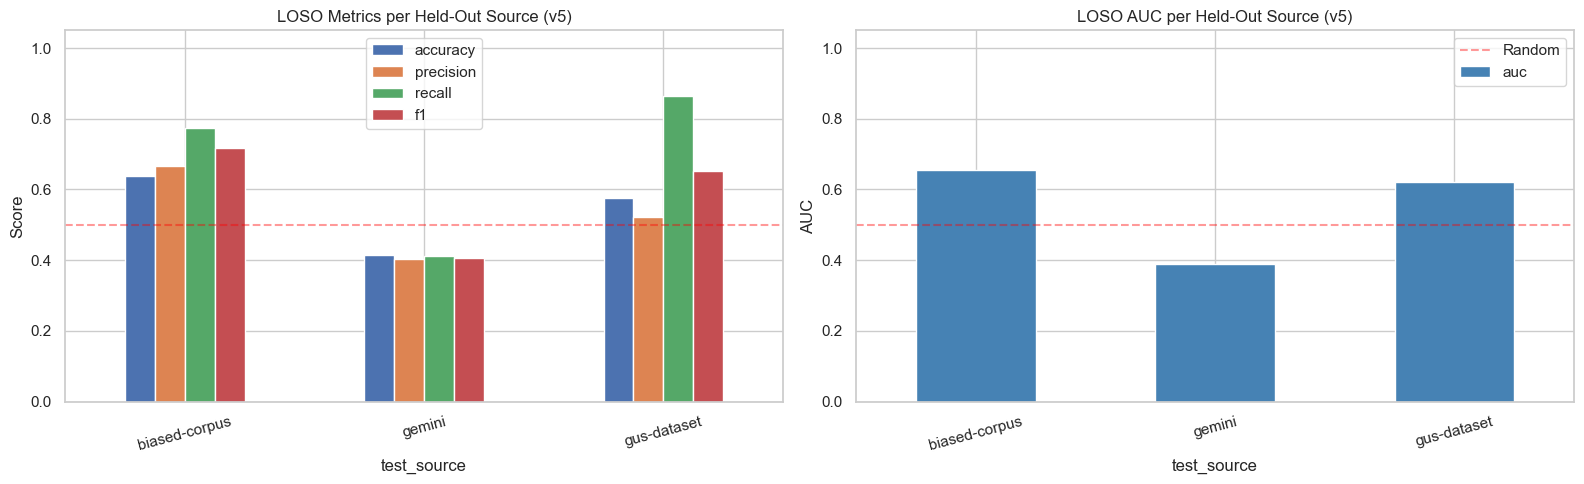

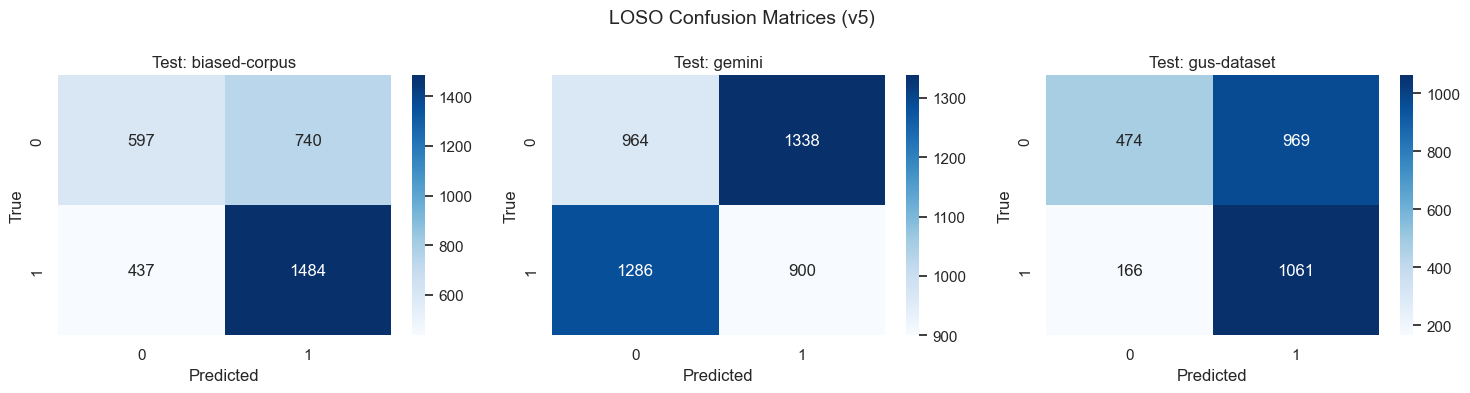

In [ ]:
print('=' * 72)
print('LOSO SUMMARY')
print('=' * 72)

df_loso = pd.DataFrame(loso_results)
print(df_loso[['test_source', 'n_train', 'n_test', 'accuracy', 'precision', 'recall', 'f1', 'auc']].to_string(index=False))

print('\nMean across LOSO folds:')
print(df_loso[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean())

# Comparison with v2 LOSO results
print('\n' + '=' * 72)
print('COMPARISON: v3 vs v5 LOSO (XGBoost)')
print('=' * 72)
v3_loso = {
    'biased-corpus': {'acc': 0.6383, 'f1': 0.7162, 'auc': 0.6629},
    'gemini':        {'acc': 0.4042, 'f1': 0.2897, 'auc': 0.4095},
    'gus-dataset':   {'acc': 0.5488, 'f1': 0.6180, 'auc': 0.7511},
}
print(f'{"Source":18} | {"v3 Acc":>7} | {"v5 Acc":>7} | {"v3 AUC":>7} | {"v5 AUC":>7}')
print('-' * 65)
for _, row in df_loso.iterrows():
    src = row['test_source']
    v3 = v3_loso.get(src, {})
    print(f'{src:18} | {v3.get("acc", 0):7.4f} | {row["accuracy"]:7.4f} | {v3.get("auc", 0):7.4f} | {row["auc"]:7.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
df_loso.set_index('test_source')[metrics_to_plot].plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('LOSO Metrics per Held-Out Source (v5)')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.4)

df_loso.set_index('test_source')[['auc']].plot(kind='bar', ax=axes[1], rot=15, color='steelblue')
axes[1].set_title('LOSO AUC per Held-Out Source (v5)')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Random')
axes[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(df_loso), figsize=(5 * len(df_loso), 4))
if len(df_loso) == 1:
    axes = [axes]
for i, row in df_loso.iterrows():
    cm = np.array(row['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Test: {row["test_source"]}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.suptitle('LOSO Confusion Matrices (v5)', fontsize=14)
plt.tight_layout()
plt.show()

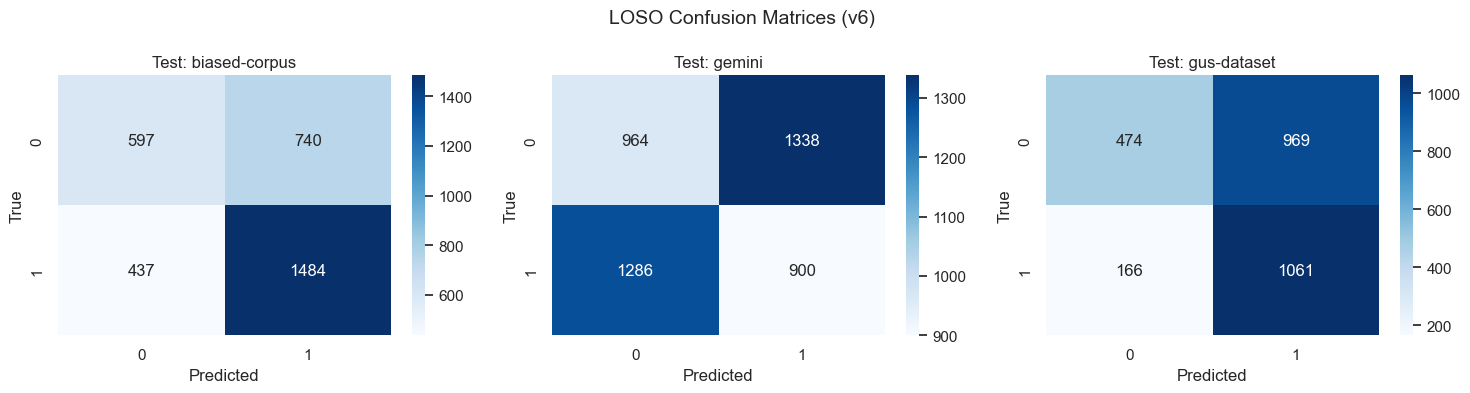

In [ ]:
fig, axes = plt.subplots(1, len(df_loso), figsize=(5 * len(df_loso), 4))
if len(df_loso) == 1:
    axes = [axes]
for i, row in df_loso.iterrows():
    cm = np.array(row['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Test: {row["test_source"]}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.suptitle('LOSO Confusion Matrices (v6)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Source Classifier: Predict Dataset Origin

Train a multiclass classifier to predict the source from the same BERT attention features.
If accuracy is much higher than the random baseline, the features encode source/domain information.

Source labels: ['biased-corpus', 'gemini', 'gus-dataset']
Source distribution: {0: 3258, 1: 4488, 2: 2670}
Random baseline: 33.3%

Train: 8328 | Test: 2088

Training source classifiers (3-way)...
  LogReg       CV Accuracy:   0.7147 (+/- 0.0119)
  LogReg       Test Accuracy: 0.7337
  XGBoost      CV Accuracy:   0.7134 (+/- 0.0150)
  XGBoost      Test Accuracy: 0.7366

Source Classifier (XGBoost) - Test Accuracy: 0.7366
Random baseline: 0.3333 (3 classes)
v3 source classifier accuracy: (fill after running v3)

Classification Report:
               precision    recall  f1-score   support

biased-corpus       0.56      0.72      0.63       604
       gemini       0.93      0.90      0.91       967
  gus-dataset       0.62      0.45      0.52       517

     accuracy                           0.74      2088
    macro avg       0.70      0.69      0.69      2088
 weighted avg       0.75      0.74      0.74      2088

Confusion Matrix:
               biased-corpus  gemini  gus-dataset
biased

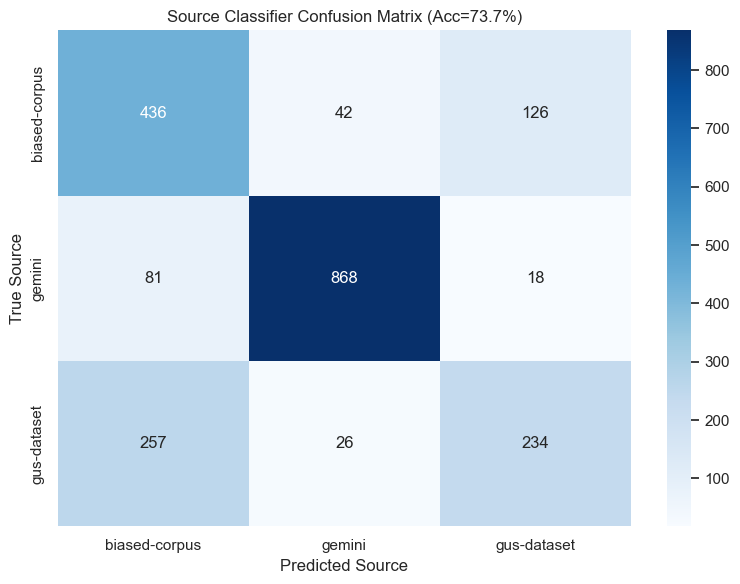

In [ ]:
le = LabelEncoder()
y_source = le.fit_transform(sources)

print(f'Source labels: {list(le.classes_)}')
print(f'Source distribution: {dict(Counter(y_source))}')
print(f'Random baseline: {1 / len(le.classes_):.1%}')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx_src, test_idx_src = next(gss.split(X_final, y_source, groups=groups))

X_train_src = X_final.iloc[train_idx_src]
X_test_src = X_final.iloc[test_idx_src]
y_train_src = y_source[train_idx_src]
y_test_src = y_source[test_idx_src]
groups_train_src = groups[train_idx_src]

print(f'\nTrain: {len(X_train_src)} | Test: {len(X_test_src)}')

src_models = {
    'LogReg': LogisticRegression(solver='lbfgs', max_iter=1000),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
    ),
}

cv_src = StratifiedGroupKFold(n_splits=5)
best_src_pred = None
best_src_acc = -1
best_src_name = None

print(f'\nTraining source classifiers ({len(le.classes_)}-way)...')
for name, model in src_models.items():
    src_pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])

    cv_scores = cross_validate(
        src_pipeline,
        X_train_src,
        y_train_src,
        cv=cv_src,
        scoring='accuracy',
        groups=groups_train_src,
    )
    print(f'  {name:12} CV Accuracy:   {cv_scores["test_score"].mean():.4f} (+/- {cv_scores["test_score"].std():.4f})')

    src_pipeline.fit(X_train_src, y_train_src)
    y_pred_src = src_pipeline.predict(X_test_src)
    acc = accuracy_score(y_test_src, y_pred_src)
    print(f'  {name:12} Test Accuracy: {acc:.4f}')

    if acc > best_src_acc:
        best_src_acc = acc
        best_src_pred = y_pred_src
        best_src_name = name

print('\n' + '=' * 64)
print(f'Source Classifier ({best_src_name}) - Test Accuracy: {best_src_acc:.4f}')
print(f'Random baseline: {1 / len(le.classes_):.4f} ({len(le.classes_)} classes)')
print(f'v3 source classifier accuracy: (fill after running v3)')
print('=' * 64)
print('\nClassification Report:')
print(classification_report(y_test_src, best_src_pred, target_names=le.classes_, zero_division=0))

cm_src = confusion_matrix(y_test_src, best_src_pred)
print('Confusion Matrix:')
print(pd.DataFrame(cm_src, index=le.classes_, columns=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_src, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Source')
plt.ylabel('True Source')
plt.title(f'Source Classifier Confusion Matrix (Acc={best_src_acc:.1%})')
plt.tight_layout()
plt.show()

## 7. Bias Classifier on Original Features

Train/test the bias classifier with a **pair-aware** group split. Counterfactuals are used as training augmentation only — the test set contains only originals and unpaired entries (simulating real-world data). All members of a counterfactual pair stay in the same split to prevent leakage.

In [ ]:
# === Pair-aware split: CFs in train only, test = originals + unpaired ===

# Step 1: Identify CF and non-CF entries by position
is_cf = (df_features['role'] == 'counterfactual').values
non_cf_positions = np.where(~is_cf)[0]
cf_positions = np.where(is_cf)[0]

print(f'Non-CF entries (originals + unpaired): {len(non_cf_positions)}')
print(f'Counterfactual entries: {len(cf_positions)}')

# Step 2: Build pair_id-based groups for non-CF entries
non_cf_pair_ids = df_features.iloc[non_cf_positions]['pair_id'].copy()
mask_no_pair = non_cf_pair_ids.isna()
non_cf_pair_ids[mask_no_pair] = ['unpaired_' + str(i) for i in range(mask_no_pair.sum())]
non_cf_groups = non_cf_pair_ids.values

X_non_cf = X_final.iloc[non_cf_positions]
y_non_cf = y.iloc[non_cf_positions]

# Step 3: GroupShuffleSplit on non-CF data only
gss_bias = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_noncf_local, test_noncf_local = next(gss_bias.split(X_non_cf, y_non_cf, groups=non_cf_groups))

# Convert local indices back to global positional indices
train_noncf_positions = non_cf_positions[train_noncf_local]
test_positions = non_cf_positions[test_noncf_local]

# Step 4: Add CFs to train — only those whose pair's original is in train
train_pair_ids = set(df_features.iloc[train_noncf_positions]['pair_id'].dropna())
cf_pair_ids = df_features.iloc[cf_positions]['pair_id']
cf_in_train_mask = cf_pair_ids.isin(train_pair_ids).values
cf_for_train_positions = cf_positions[cf_in_train_mask]
cf_excluded_positions = cf_positions[~cf_in_train_mask]

train_idx = np.concatenate([train_noncf_positions, cf_for_train_positions])
test_idx = test_positions

X_train = X_final.iloc[train_idx]
X_test = X_final.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Groups for training set (needed for group-aware CV)
train_group_col = df_features.iloc[train_idx]['pair_id'].copy()
mask_no = train_group_col.isna()
train_group_col[mask_no] = ['unpaired_' + str(i) for i in range(mask_no.sum())]
groups_train = train_group_col.values

print(f'\n=== Split Summary ===')
print(f'Training Set: {X_train.shape[0]} samples')
print(f'  - Originals + unpaired: {len(train_noncf_positions)}')
print(f'  - Counterfactuals (augmentation): {len(cf_for_train_positions)}')
print(f'Testing Set:  {X_test.shape[0]} samples (originals + unpaired only)')
print(f'Excluded CFs (pair in test): {len(cf_excluded_positions)}')

# Leakage checks
train_texts = set(df_features.iloc[train_idx]['text'])
test_texts = set(df_features.iloc[test_idx]['text'])
overlap = train_texts & test_texts
print(f'\nLeakage Check:')
print(f'  Text overlap: {len(overlap)} (should be 0)')
assert len(overlap) == 0, 'LEAKAGE DETECTED: overlapping texts between train and test!'

train_pairs = set(df_features.iloc[train_idx]['pair_id'].dropna())
test_pairs = set(df_features.iloc[test_idx]['pair_id'].dropna())
pair_overlap = train_pairs & test_pairs
print(f'  Pair_id overlap: {len(pair_overlap)} (should be 0)')
assert len(pair_overlap) == 0, 'LEAKAGE DETECTED: pair_id shared between train and test!'

# Source distribution check
print(f'\nSource Distribution:')
train_sources_dist = pd.Series(sources[train_idx]).value_counts(normalize=True)
test_sources_dist = pd.Series(sources[test_idx]).value_counts(normalize=True)
source_df = pd.DataFrame({'train': train_sources_dist, 'test': test_sources_dist}).fillna(0)
source_df['diff'] = (source_df['train'] - source_df['test']).abs()
print(source_df.round(3).to_string())

# Label distribution check
print(f'\nLabel Distribution:')
print(f'  Train: biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())} ({y_train.mean():.1%} biased)')
print(f'  Test:  biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())} ({y_test.mean():.1%} biased)')

# --- Model Comparison ---
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        alpha=0.01,
        random_state=RANDOM_STATE,
    ),
}

results = {}
cv = StratifiedGroupKFold(n_splits=5)

print('\nComparing models (original features)')
for name, model in models.items():
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        groups=groups_train,
    )
    results[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | '
        f'AUC: {results[name]["auc"]:.4f} | '
        f'Acc: {results[name]["accuracy"]:.4f} | '
        f'Prec: {results[name]["precision"]:.4f} | '
        f'Rec: {results[name]["recall"]:.4f} | '
        f'F1: {results[name]["f1"]:.4f}'
    )

best_model_name = max(results, key=lambda name: results[name]['auc'])
print(f'\nBest model: {best_model_name} (AUC={results[best_model_name]["auc"]:.4f})')

Non-CF entries (originals + unpaired): 6515
Counterfactual entries: 3901

=== Split Summary ===
Training Set: 7795 samples
  - Originals + unpaired: 4886
  - Counterfactuals (augmentation): 2909
Testing Set:  1629 samples (originals + unpaired only)
Excluded CFs (pair in test): 992

Leakage Check:
  Text overlap: 0 (should be 0)
  Pair_id overlap: 0 (should be 0)

Source Distribution:
               train   test   diff
gemini         0.422  0.379  0.043
biased-corpus  0.319  0.335  0.016
gus-dataset    0.259  0.287  0.028

Label Distribution:
  Train: biased=4009, neutral=3786 (51.4% biased)
  Test:  biased=640, neutral=989 (39.3% biased)

Comparing models (original features)
LogReg       | AUC: 0.8476 | Acc: 0.7643 | Prec: 0.7578 | Rec: 0.7965 | F1: 0.7766
RandomForest | AUC: 0.8342 | Acc: 0.7559 | Prec: 0.7340 | Rec: 0.8239 | F1: 0.7763
XGBoost      | AUC: 0.8625 | Acc: 0.7806 | Prec: 0.7602 | Rec: 0.8379 | F1: 0.7971
MLP          | AUC: 0.8577 | Acc: 0.7764 | Prec: 0.7590 | Rec: 0.8

In [ ]:
param_grids = {
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7],
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
    'LogReg': {
        'm__C': [0.1, 1.0, 10.0],
    },
}

print(f'Tuning {best_model_name}...')
pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name]),
])

search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_grids[best_model_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search.fit(X_train, y_train, groups=groups_train)

print(f'Best params: {search.best_params_}')
final_model = search.best_estimator_

Tuning XGBoost...
Best params: {'m__n_estimators': 200, 'm__max_depth': 5, 'm__learning_rate': 0.1}


Final Test Set Results (original features)
AUC:       0.8725
Accuracy:  0.7901
Precision: 0.6925
Recall:    0.8375
F1:        0.7581

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81       989
           1       0.69      0.84      0.76       640

    accuracy                           0.79      1629
   macro avg       0.79      0.80      0.79      1629
weighted avg       0.81      0.79      0.79      1629



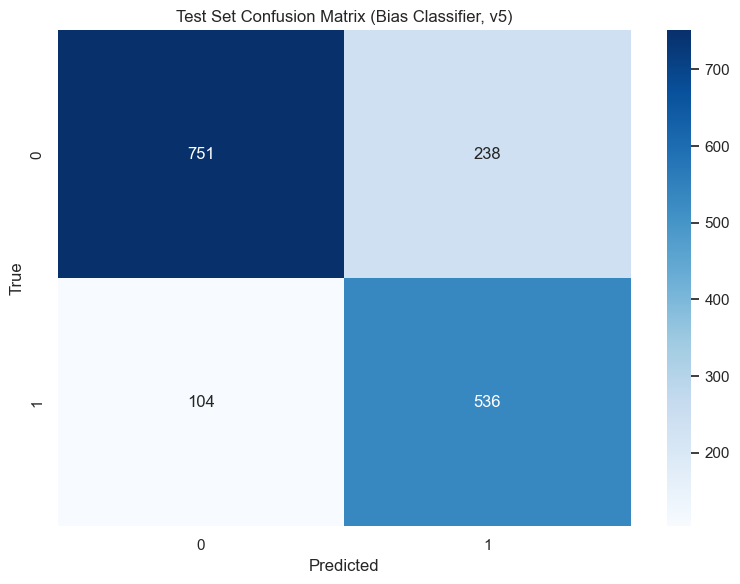

In [ ]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

orig_auc = roc_auc_score(y_test, y_test_prob)
orig_acc = accuracy_score(y_test, y_test_pred)
orig_prec = precision_score(y_test, y_test_pred, zero_division=0)
orig_rec = recall_score(y_test, y_test_pred, zero_division=0)
orig_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print('Final Test Set Results (original features)')
print(f'AUC:       {orig_auc:.4f}')
print(f'Accuracy:  {orig_acc:.4f}')
print(f'Precision: {orig_prec:.4f}')
print(f'Recall:    {orig_rec:.4f}')
print(f'F1:        {orig_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Test Set Confusion Matrix (Bias Classifier, v5)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

### 7.1 Counterfactual Consistency Evaluation

Measure whether the model correctly flips its prediction when moving from an original sentence to its counterfactual pair. A faithful bias detector should predict the original label correctly AND flip for the CF.

Counterfactual Consistency Analysis

Total counterfactual pairs evaluated: 3901
  Held-out pairs (original in test set): 992

--- ALL PAIRS (3901 pairs) ---
  Both predictions correct (full consistency): 86.9%
  Original correctly predicted:                 94.5%
  Counterfactual correctly predicted:           91.0%
  Probability direction correct:                95.6%
  Mean probability delta (|P(orig) - P(cf)|):  0.641

--- HELD-OUT PAIRS ONLY (992 pairs) ---
  Both predictions correct (full consistency): 61.8%
  Original correctly predicted:                 82.5%
  Counterfactual correctly predicted:           74.0%
  Probability direction correct:                83.3%
  Mean probability delta (|P(orig) - P(cf)|):  0.492

--- Consistency by Source ---
  gemini            : consistency=94.2%  direction=98.9%  n=2181
  gus-dataset       : consistency=78.4%  direction=92.1%  n=751
  biased-corpus     : consistency=77.0%  direction=90.7%  n=969

--- Top 10 Inconsistent Pairs (lowest pro

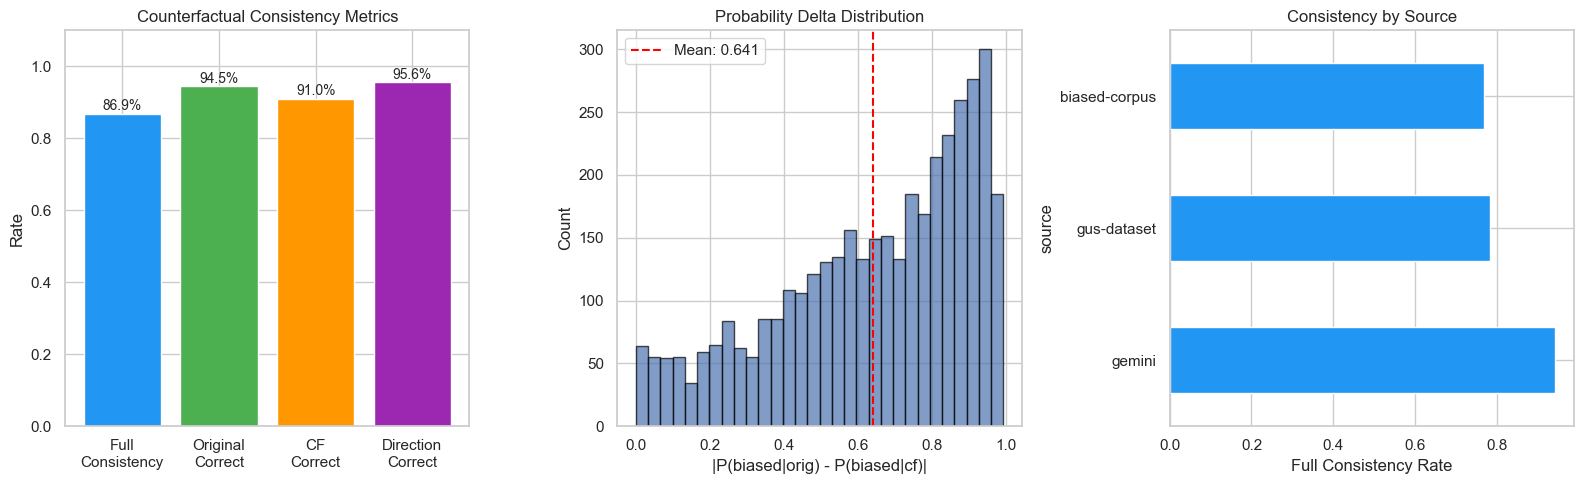

In [ ]:
# === Counterfactual Consistency Evaluation ===
print('Counterfactual Consistency Analysis')
print('=' * 60)

paired_entries = df_features[df_features['pair_id'].notna()].copy()
pair_groups = paired_entries.groupby('pair_id')

test_idx_set = set(test_idx)
results_cc = []

for pid, group in pair_groups:
    orig = group[group['role'] == 'original']
    cf = group[group['role'] == 'counterfactual']
    if len(orig) != 1 or len(cf) != 1:
        continue

    orig_pos = orig.index[0]
    cf_pos = cf.index[0]

    X_orig = X_final.iloc[[orig_pos]]
    X_cf = X_final.iloc[[cf_pos]]

    pred_orig = final_model.predict(X_orig)[0]
    pred_cf = final_model.predict(X_cf)[0]
    prob_orig = final_model.predict_proba(X_orig)[0, 1]
    prob_cf = final_model.predict_proba(X_cf)[0, 1]

    label_orig = int(y.iloc[orig_pos])
    label_cf = int(y.iloc[cf_pos])

    orig_correct = (pred_orig == label_orig)
    cf_correct = (pred_cf == label_cf)
    both_correct = orig_correct and cf_correct

    if label_orig > label_cf:
        direction_correct = prob_orig > prob_cf
    elif label_orig < label_cf:
        direction_correct = prob_cf > prob_orig
    else:
        direction_correct = True

    prob_delta = abs(prob_orig - prob_cf)

    # Determine which positional index to check for held-out status
    # orig_pos is the DataFrame index; we need to check if it's in test_idx (positional)
    is_held_out = orig_pos in test_idx_set

    results_cc.append({
        'pair_id': pid,
        'text_orig': orig['text'].values[0][:80],
        'text_cf': cf['text'].values[0][:80],
        'label_orig': label_orig,
        'label_cf': label_cf,
        'pred_orig': pred_orig,
        'pred_cf': pred_cf,
        'prob_orig': prob_orig,
        'prob_cf': prob_cf,
        'prob_delta': prob_delta,
        'orig_correct': orig_correct,
        'cf_correct': cf_correct,
        'both_correct': both_correct,
        'direction_correct': direction_correct,
        'source': orig['source_canonical'].values[0],
        'is_held_out': is_held_out,
    })

df_cc = pd.DataFrame(results_cc)
df_cc_heldout = df_cc[df_cc['is_held_out']]

print(f'\nTotal counterfactual pairs evaluated: {len(df_cc)}')
print(f'  Held-out pairs (original in test set): {len(df_cc_heldout)}')

for label, subset in [('ALL PAIRS', df_cc), ('HELD-OUT PAIRS ONLY', df_cc_heldout)]:
    if len(subset) == 0:
        continue
    print(f'\n--- {label} ({len(subset)} pairs) ---')
    print(f'  Both predictions correct (full consistency): {subset["both_correct"].mean():.1%}')
    print(f'  Original correctly predicted:                 {subset["orig_correct"].mean():.1%}')
    print(f'  Counterfactual correctly predicted:           {subset["cf_correct"].mean():.1%}')
    print(f'  Probability direction correct:                {subset["direction_correct"].mean():.1%}')
    print(f'  Mean probability delta (|P(orig) - P(cf)|):  {subset["prob_delta"].mean():.3f}')

print(f'\n--- Consistency by Source ---')
for src in df_cc['source'].unique():
    sub = df_cc[df_cc['source'] == src]
    print(f'  {src:18s}: consistency={sub["both_correct"].mean():.1%}  direction={sub["direction_correct"].mean():.1%}  n={len(sub)}')

# Failure analysis
failures = df_cc[~df_cc['both_correct']].sort_values('prob_delta', ascending=True)
print(f'\n--- Top 10 Inconsistent Pairs (lowest probability delta) ---')
for _, row in failures.head(10).iterrows():
    print(f'  [{row["source"]}] orig={row["label_orig"]}->pred={row["pred_orig"]} (p={row["prob_orig"]:.2f})  |  '
          f'cf={row["label_cf"]}->pred={row["pred_cf"]} (p={row["prob_cf"]:.2f})  delta={row["prob_delta"]:.3f}')
    print(f'    ORIG: {row["text_orig"]}')
    print(f'    CF:   {row["text_cf"]}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['both_correct', 'orig_correct', 'cf_correct', 'direction_correct']
labels_m = ['Full\nConsistency', 'Original\nCorrect', 'CF\nCorrect', 'Direction\nCorrect']
vals = [df_cc[m].mean() for m in metrics]
bars = axes[0].bar(labels_m, vals, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.1%}',
                 ha='center', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Rate')
axes[0].set_title('Counterfactual Consistency Metrics')

axes[1].hist(df_cc['prob_delta'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df_cc['prob_delta'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_cc["prob_delta"].mean():.3f}')
axes[1].set_xlabel('|P(biased|orig) - P(biased|cf)|')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability Delta Distribution')
axes[1].legend()

src_consistency = df_cc.groupby('source')['both_correct'].mean().sort_values(ascending=False)
src_consistency.plot(kind='barh', ax=axes[2], color='#2196F3')
axes[2].set_xlabel('Full Consistency Rate')
axes[2].set_title('Consistency by Source')

plt.tight_layout()
plt.show()

In [ ]:
test_texts_arr = df_features.iloc[test_idx]['text'].values
test_sources = df_features.iloc[test_idx]['source_canonical'].values

errors_mask = y_test.values != y_test_pred
false_positives = (y_test.values == 0) & (y_test_pred == 1)
false_negatives = (y_test.values == 1) & (y_test_pred == 0)

print(f'Total test: {len(y_test)}')
print(f'Total errors: {int(errors_mask.sum())} ({errors_mask.sum() / len(y_test) * 100:.2f}%)')
print(f'  False positives: {int(false_positives.sum())}')
print(f'  False negatives: {int(false_negatives.sum())}')

print('\nErrors by source:')
print(f'  {"Source":18} {"Errors":>6} / {"Total":>6}  {"Rate":>6}')
for source in unique_sources:
    source_mask = test_sources == source
    source_errors = errors_mask & source_mask
    source_total = int(source_mask.sum())
    source_rate = source_errors.sum() / source_total if source_total else 0
    print(f'  {source:18} {int(source_errors.sum()):6d} / {source_total:6d}  {source_rate * 100:5.1f}%')

error_df = pd.DataFrame({
    'text': test_texts_arr[errors_mask],
    'true_label': y_test.values[errors_mask],
    'pred_label': y_test_pred[errors_mask],
    'source': test_sources[errors_mask],
})


def classify_text_type(text: str) -> str:
    text_lower = text.lower().strip()
    if text_lower.endswith('?') or text_lower.startswith(('what', 'why', 'how', 'when', 'where', 'who', 'can', 'is', 'are', 'do', 'does')):
        return 'question'
    if any(kw in text_lower for kw in ['study', 'research', 'data', 'evidence', 'analysis', 'experiment', 'theory', 'hypothesis']):
        return 'technical_scientific'
    if any(text_lower.startswith(prefix) for prefix in ['that person', 'they', 'someone', 'a person']):
        return 'neutral_descriptive'
    return 'statement'


error_df['text_type'] = error_df['text'].apply(classify_text_type)
error_df['error_type'] = error_df['true_label'].map({0: 'FP (neutral->biased)', 1: 'FN (biased->neutral)'})

print('\nErrors by text type:')
print(pd.crosstab(error_df['text_type'], error_df['error_type'], margins=True))

fp_df = error_df[error_df['true_label'] == 0]
fn_df = error_df[error_df['true_label'] == 1]
print('\nSample errors:')
print(f'  False positives: {len(fp_df)} total')
for _, row in fp_df.sample(n=min(5, len(fp_df)), random_state=RANDOM_STATE).iterrows():
    print(f'    [{row["source"]}] ({row["text_type"]}) {row["text"]}')

print(f'\n  False negatives: {len(fn_df)} total')
for _, row in fn_df.sample(n=min(5, len(fn_df)), random_state=RANDOM_STATE).iterrows():
    print(f'    [{row["source"]}] ({row["text_type"]}) {row["text"]}')

error_path = notebook_dir / 'error_analysis_source_diagnosis_v5.csv'
error_df.to_csv(error_path, index=False)
print(f'\nSaved full error analysis to: {error_path}')

Total test: 1629
Total errors: 342 (20.99%)
  False positives: 238
  False negatives: 104

Errors by source:
  Source             Errors /  Total    Rate
  biased-corpus         178 /    545   32.7%
  gemini                 50 /    617    8.1%
  gus-dataset           114 /    467   24.4%

Errors by text type:
error_type            FN (biased->neutral)  FP (neutral->biased)  All
text_type                                                            
neutral_descriptive                      4                     6   10
question                                25                    86  111
statement                               73                   138  211
technical_scientific                     2                     8   10
All                                    104                   238  342

Sample errors:
  False positives: 238 total
    [biased-corpus] (statement) LGBTQ+ folks are universally accepted by all communities.
    [biased-corpus] (question) Why aren't progressives held acco

## 8. Residualization: Remove Source Signal from Features

For each feature, regress it against one-hot encoded source labels and keep the residuals.
If the source classifier collapses on residualized features, source information has been removed.
If the bias classifier still performs well, it suggests the model retains genuine bias signal.

In [ ]:
source_dummies = pd.get_dummies(df_features['source_canonical'], drop_first=False).values
print(f'Source dummies shape: {source_dummies.shape}')
print(f'Original features shape: {X_final.shape}')

X_residual = X_final.copy()
lr = LinearRegression()

for col in X_final.columns:
    feature_values = X_final[col].values.reshape(-1, 1)
    lr.fit(source_dummies, feature_values)
    predicted_by_source = lr.predict(source_dummies)
    X_residual[col] = feature_values.ravel() - predicted_by_source.ravel()

print(f'\nResidualized features shape: {X_residual.shape}')

y_source_check = LabelEncoder().fit_transform(sources)
source_check_pipe = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
])

tr_idx, te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE).split(X_residual, y_source_check, groups=groups))
source_check_pipe.fit(X_residual.iloc[tr_idx], y_source_check[tr_idx])
src_acc_residual = accuracy_score(y_source_check[te_idx], source_check_pipe.predict(X_residual.iloc[te_idx]))

print('\nSource classifier accuracy:')
print(f'  Before residualization: {best_src_acc:.4f}')
print(f'  After residualization:  {src_acc_residual:.4f}')
print(f'  Random baseline:        {1 / len(unique_sources):.4f}')

Source dummies shape: (10416, 3)
Original features shape: (10416, 3238)

Residualized features shape: (10416, 3238)

Source classifier accuracy:
  Before residualization: 0.7366
  After residualization:  0.3895
  Random baseline:        0.3333


### 8.1 LOSO on Residualized Features

In [ ]:
print('LOSO on residualized features')
print('=' * 72 + '\n')

loso_resid_results = []

for test_source in unique_sources:
    print(f'--- Test on [{test_source}] ---')

    test_mask = sources == test_source
    train_mask = ~test_mask

    X_train_r = X_residual.iloc[np.where(train_mask)[0]]
    X_test_r = X_residual.iloc[np.where(test_mask)[0]]
    y_train_r = y.iloc[np.where(train_mask)[0]]
    y_test_r = y.iloc[np.where(test_mask)[0]]

    print(f'  Train: {len(X_train_r)} | Test: {len(X_test_r)}')
    print(f'  Test labels: biased={int(y_test_r.sum())}, neutral={int((y_test_r == 0).sum())}')

    pipeline_r = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
        )),
    ])

    pipeline_r.fit(X_train_r, y_train_r)
    y_pred_r = pipeline_r.predict(X_test_r)
    y_prob_r = pipeline_r.predict_proba(X_test_r)[:, 1]

    acc = accuracy_score(y_test_r, y_pred_r)
    prec = precision_score(y_test_r, y_pred_r, zero_division=0)
    rec = recall_score(y_test_r, y_pred_r, zero_division=0)
    f1 = f1_score(y_test_r, y_pred_r, zero_division=0)
    auc = roc_auc_score(y_test_r, y_prob_r)
    cm = confusion_matrix(y_test_r, y_pred_r)

    print(f'  Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}')
    print(f'  CM: {cm.tolist()}\n')

    loso_resid_results.append({
        'test_source': test_source,
        'n_test': len(X_test_r),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

df_loso_resid = pd.DataFrame(loso_resid_results)

LOSO on residualized features

--- Test on [biased-corpus] ---
  Train: 7158 | Test: 3258
  Test labels: biased=1921, neutral=1337
  Acc=0.5878 | Prec=0.6636 | Rec=0.6101 | F1=0.6357 | AUC=0.6170
  CM: [[743, 594], [749, 1172]]

--- Test on [gemini] ---
  Train: 5928 | Test: 4488
  Test labels: biased=2186, neutral=2302
  Acc=0.5853 | Prec=0.5888 | Rec=0.4927 | F1=0.5365 | AUC=0.6160
  CM: [[1550, 752], [1109, 1077]]

--- Test on [gus-dataset] ---
  Train: 7746 | Test: 2670
  Test labels: biased=1227, neutral=1443
  Acc=0.5034 | Prec=0.4600 | Rec=0.4645 | F1=0.4623 | AUC=0.5421
  CM: [[774, 669], [657, 570]]



COMPARISON: Original vs Residualized LOSO (v5)
  test_source  accuracy_original  f1_original  auc_original  accuracy_residual  f1_residual  auc_residual
biased-corpus           0.638735     0.716043      0.654983           0.587784     0.635747      0.617021
       gemini           0.415330     0.406872      0.389621           0.585339     0.536488      0.615996
  gus-dataset           0.574906     0.651520      0.622425           0.503371     0.462287      0.542066


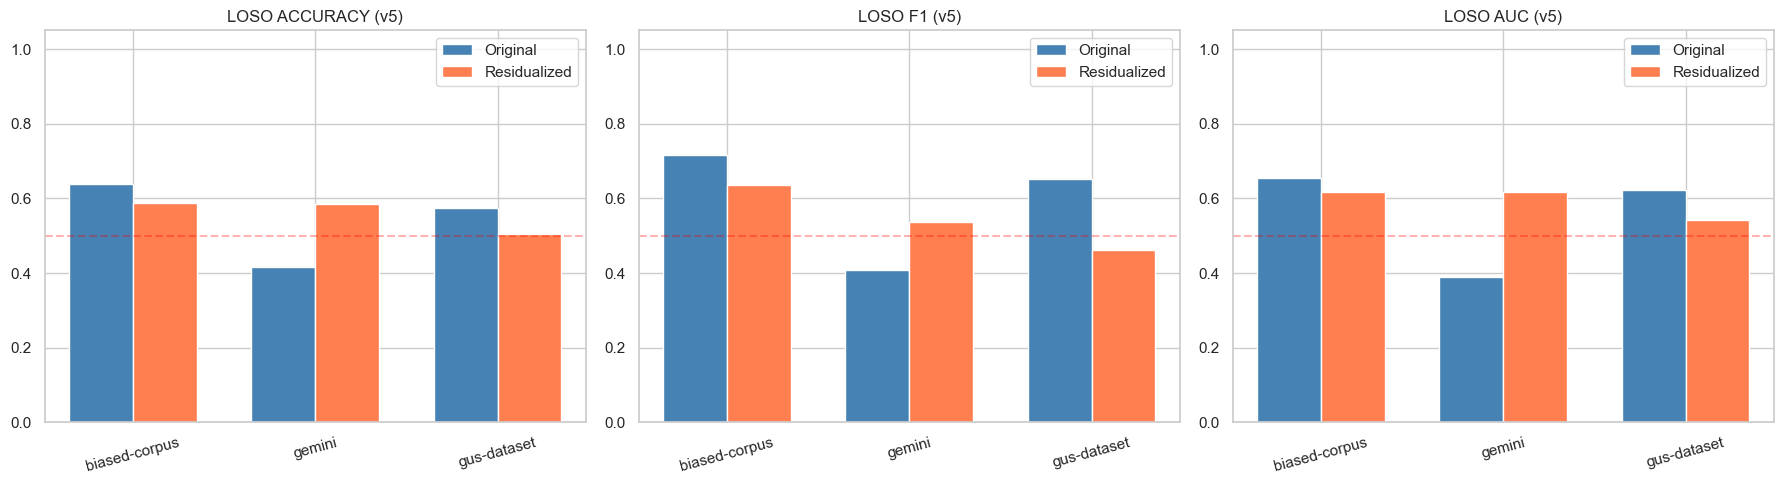

In [ ]:
print('=' * 72)
print('COMPARISON: Original vs Residualized LOSO (v5)')
print('=' * 72)

comparison = df_loso[['test_source', 'accuracy', 'f1', 'auc']].merge(
    df_loso_resid[['test_source', 'accuracy', 'f1', 'auc']],
    on='test_source',
    suffixes=('_original', '_residual'),
)
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['accuracy', 'f1', 'auc']):
    orig_col = f'{metric}_original'
    resid_col = f'{metric}_residual'
    x = np.arange(len(comparison))
    width = 0.35
    axes[i].bar(x - width / 2, comparison[orig_col], width, label='Original', color='steelblue')
    axes[i].bar(x + width / 2, comparison[resid_col], width, label='Residualized', color='coral')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(comparison['test_source'], rotation=15)
    axes[i].set_title(f'LOSO {metric.upper()} (v5)')
    axes[i].set_ylim(0, 1.05)
    axes[i].axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
    axes[i].legend()
plt.tight_layout()
plt.show()

## 9. Bias Classifier on Residualized Features

Repeat the bias-classification workflow after removing source signal.

In [ ]:
X_train_res = X_residual.iloc[train_idx]
X_test_res = X_residual.iloc[test_idx]

models_res = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx',
        max_depth=8,
        n_estimators=500,
        learning_rate=0.05,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        alpha=0.01,
        random_state=RANDOM_STATE,
    ),
}

results_res = {}
cv_res = StratifiedGroupKFold(n_splits=5)

print(f'Train: {len(X_train_res)} | Test: {len(X_test_res)}')
print(f'Label distribution (train): biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())}')
print(f'Label distribution (test):  biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())}')
print('\nComparing models on residualized features')

for name, model in models_res.items():
    pipeline_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scores = cross_validate(
        pipeline_res,
        X_train_res,
        y_train,
        cv=cv_res,
        scoring=['roc_auc', 'accuracy', 'precision', 'recall', 'f1'],
        groups=groups_train,
    )
    results_res[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | '
        f'AUC: {results_res[name]["auc"]:.4f} | '
        f'Acc: {results_res[name]["accuracy"]:.4f} | '
        f'Prec: {results_res[name]["precision"]:.4f} | '
        f'Rec: {results_res[name]["recall"]:.4f} | '
        f'F1: {results_res[name]["f1"]:.4f}'
    )

best_res_name = max(results_res, key=lambda name: results_res[name]['auc'])
print(f'\nBest residualized model: {best_res_name} (AUC={results_res[best_res_name]["auc"]:.4f})')

Train: 7795 | Test: 1629
Label distribution (train): biased=4009, neutral=3786
Label distribution (test):  biased=640, neutral=989

Comparing models on residualized features
LogReg       | AUC: 0.8434 | Acc: 0.7632 | Prec: 0.7633 | Rec: 0.7820 | F1: 0.7726
RandomForest | AUC: 0.8629 | Acc: 0.7709 | Prec: 0.7590 | Rec: 0.8127 | F1: 0.7849
XGBoost      | AUC: 0.8790 | Acc: 0.7911 | Prec: 0.7804 | Rec: 0.8266 | F1: 0.8028
MLP          | AUC: 0.8559 | Acc: 0.7752 | Prec: 0.7759 | Rec: 0.7922 | F1: 0.7838

Best residualized model: XGBoost (AUC=0.8790)


Tuning XGBoost on residualized features...
Best params: {'m__n_estimators': 100, 'm__max_depth': 7, 'm__learning_rate': 0.1}

Final Test: Residualized Features (v5)
AUC:       0.8739
Accuracy:  0.8011
Precision: 0.7068
Recall:    0.8438
F1:        0.7692

Classification Report (Residualized):
              precision    recall  f1-score   support

           0       0.88      0.77      0.83       989
           1       0.71      0.84      0.77       640

    accuracy                           0.80      1629
   macro avg       0.80      0.81      0.80      1629
weighted avg       0.81      0.80      0.80      1629



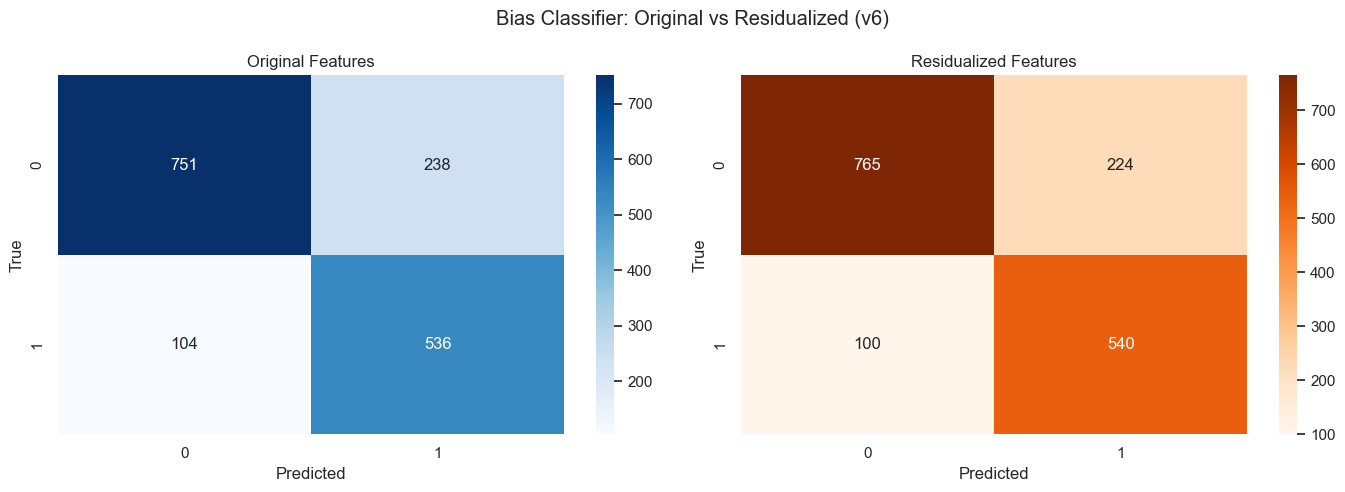


COMPARISON: Original vs Residualized (Test Set)
Metric       |   Original | Residualized |    Delta
----------------------------------------------------
AUC          |     0.8725 |       0.8739 |  +0.0015
Accuracy     |     0.7901 |       0.8011 |  +0.0110
F1           |     0.7581 |       0.7692 |  +0.0111
Precision    |     0.6925 |       0.7068 |  +0.0143
Recall       |     0.8375 |       0.8438 |  +0.0062


In [ ]:
print(f'Tuning {best_res_name} on residualized features...')
pipeline_res = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models_res[best_res_name]),
])

search_res = HalvingRandomSearchCV(
    pipeline_res,
    param_distributions=param_grids[best_res_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search_res.fit(X_train_res, y_train, groups=groups_train)

print(f'Best params: {search_res.best_params_}')
final_model_res = search_res.best_estimator_

y_test_pred_res = final_model_res.predict(X_test_res)
y_test_prob_res = final_model_res.predict_proba(X_test_res)[:, 1]

auc_res = roc_auc_score(y_test, y_test_prob_res)
acc_res = accuracy_score(y_test, y_test_pred_res)
prec_res = precision_score(y_test, y_test_pred_res, zero_division=0)
rec_res = recall_score(y_test, y_test_pred_res, zero_division=0)
f1_res = f1_score(y_test, y_test_pred_res, zero_division=0)

print('\n' + '=' * 60)
print('Final Test: Residualized Features (v5)')
print('=' * 60)
print(f'AUC:       {auc_res:.4f}')
print(f'Accuracy:  {acc_res:.4f}')
print(f'Precision: {prec_res:.4f}')
print(f'Recall:    {rec_res:.4f}')
print(f'F1:        {f1_res:.4f}')
print('\nClassification Report (Residualized):')
print(classification_report(y_test, y_test_pred_res, zero_division=0))

cm_orig = confusion_matrix(y_test, y_test_pred)
cm_res = confusion_matrix(y_test, y_test_pred_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Original Features')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Oranges', ax=ax2)
ax2.set_title('Residualized Features')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.suptitle('Bias Classifier: Original vs Residualized (v6)')
plt.tight_layout()
plt.show()

print('\n' + '=' * 60)
print('COMPARISON: Original vs Residualized (Test Set)')
print('=' * 60)
print(f'{"Metric":12} | {"Original":>10} | {"Residualized":>12} | {"Delta":>8}')
print('-' * 52)
print(f'{"AUC":12} | {orig_auc:10.4f} | {auc_res:12.4f} | {auc_res - orig_auc:+8.4f}')
print(f'{"Accuracy":12} | {orig_acc:10.4f} | {acc_res:12.4f} | {acc_res - orig_acc:+8.4f}')
print(f'{"F1":12} | {orig_f1:10.4f} | {f1_res:12.4f} | {f1_res - orig_f1:+8.4f}')
print(f'{"Precision":12} | {orig_prec:10.4f} | {prec_res:12.4f} | {prec_res - orig_prec:+8.4f}')
print(f'{"Recall":12} | {orig_rec:10.4f} | {rec_res:12.4f} | {rec_res - orig_rec:+8.4f}')

ERROR ANALYSIS BY SOURCE: Original vs Residualized (v5)

Source             |  Orig Errors |  Resid Errors |  Orig Rate |  Resid Rate
------------------------------------------------------------------------------
biased-corpus      |   178 / 545   |   177 / 545   |     32.7% |      32.5%
gemini             |    50 / 617   |    51 / 617   |      8.1% |       8.3%
gus-dataset        |   114 / 467   |    96 / 467   |     24.4% |      20.6%
------------------------------------------------------------------------------
TOTAL              |   342 / 1629  |   324 / 1629  |     21.0% |      19.9%


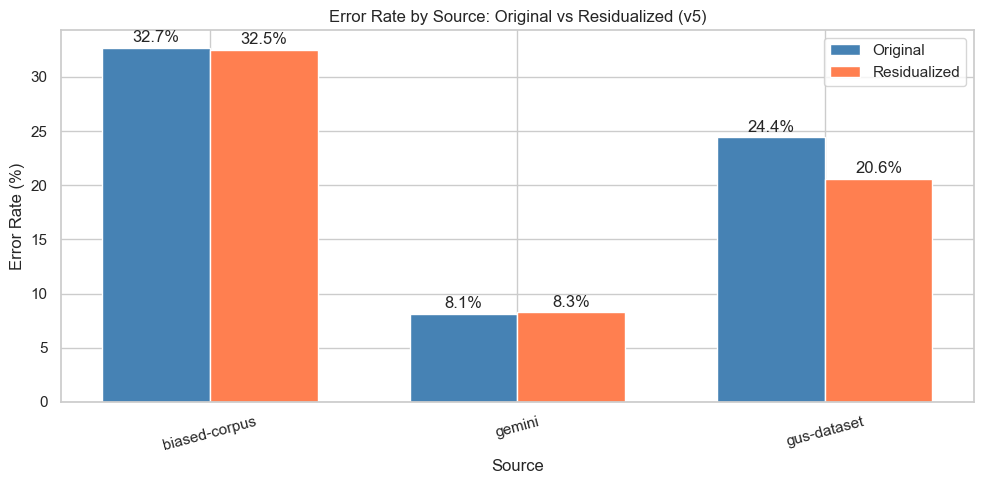

In [ ]:
test_sources_arr = df_features.iloc[test_idx]['source_canonical'].values
errors_orig = y_test.values != y_test_pred
errors_resid = y_test.values != y_test_pred_res

print('=' * 72)
print('ERROR ANALYSIS BY SOURCE: Original vs Residualized (v5)')
print('=' * 72)
print(f'\n{"Source":18} | {"Orig Errors":>12} | {"Resid Errors":>13} | {"Orig Rate":>10} | {"Resid Rate":>11}')
print('-' * 78)

orig_rates = []
resid_rates = []
for src in unique_sources:
    src_mask = test_sources_arr == src
    src_total = int(src_mask.sum())
    orig_errs = int((errors_orig & src_mask).sum())
    resid_errs = int((errors_resid & src_mask).sum())
    orig_rate = orig_errs / src_total if src_total else 0
    resid_rate = resid_errs / src_total if src_total else 0
    orig_rates.append(orig_rate)
    resid_rates.append(resid_rate)
    print(f'{src:18} | {orig_errs:5d} / {src_total:<5d} | {resid_errs:5d} / {src_total:<5d} | {orig_rate:9.1%} | {resid_rate:10.1%}')

print('-' * 78)
print(f'{"TOTAL":18} | {int(errors_orig.sum()):5d} / {len(y_test):<5d} | {int(errors_resid.sum()):5d} / {len(y_test):<5d} | {errors_orig.mean():9.1%} | {errors_resid.mean():10.1%}')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(unique_sources))
width = 0.35
bars1 = ax.bar(x - width / 2, [r * 100 for r in orig_rates], width, label='Original', color='steelblue')
bars2 = ax.bar(x + width / 2, [r * 100 for r in resid_rates], width, label='Residualized', color='coral')
ax.set_xlabel('Source')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Source: Original vs Residualized (v5)')
ax.set_xticks(x)
ax.set_xticklabels(unique_sources, rotation=15)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=2)
ax.bar_label(bars2, fmt='%.1f%%', padding=2)
plt.tight_layout()
plt.show()

## 10. Conclusions and Interpretation

In [ ]:
source_summary = df_features.groupby('source_canonical')['label'].agg(total='size', biased='sum').copy()
source_summary['neutral'] = source_summary['total'] - source_summary['biased']
source_summary['biased_rate'] = source_summary['biased'] / source_summary['total']

mean_loso_auc = df_loso['auc'].mean()
mean_loso_f1 = df_loso['f1'].mean()
mean_loso_resid_auc = df_loso_resid['auc'].mean()
mean_loso_resid_f1 = df_loso_resid['f1'].mean()

delta_auc = auc_res - orig_auc
delta_f1 = f1_res - orig_f1
source_rate_gap = source_summary['biased_rate'].max() - source_summary['biased_rate'].min()

print('=' * 72)
print('DIAGNOSTIC SUMMARY (v5)')
print('=' * 72)

print('\n1. DATASET STRUCTURE')
print(f'   - Entries: {len(df_features)}')
print(f'   - Unique texts: {df_features["text"].nunique()}')
print(f'   - Sources: {len(unique_sources)}')
for src, row in source_summary.iterrows():
    print(
        f'   - {src:18} total={int(row["total"]):4d} '
        f'biased={int(row["biased"]):4d} neutral={int(row["neutral"]):4d} '
        f'biased_rate={row["biased_rate"]:.1%}'
    )
if source_rate_gap > 0.5:
    print('   - Source and label are strongly imbalanced across sources.')
elif source_rate_gap > 0.2:
    print('   - Source and label are partially confounded across sources.')
else:
    print('   - Source and label are relatively balanced across sources.')

print('\n2. SOURCE CLASSIFIER')
print(f'   - Best source-classification accuracy: {best_src_acc:.1%}')
print(f'   - Random baseline: {1 / len(unique_sources):.1%}')
print(f'   - Residualized source accuracy: {src_acc_residual:.1%}')
print(f'   - v3 reference: (fill after running v3)')

print('\n3. LOSO GENERALIZATION')
print(f'   - Mean LOSO AUC (original):      {mean_loso_auc:.4f}')
print(f'   - Mean LOSO F1  (original):      {mean_loso_f1:.4f}')
print(f'   - Mean LOSO AUC (residualized):  {mean_loso_resid_auc:.4f}')
print(f'   - Mean LOSO F1  (residualized):  {mean_loso_resid_f1:.4f}')
print(f'   - v3 mean LOSO AUC (original):   (fill after running v3)')
print(f'   - v3 mean LOSO F1  (original):   (fill after running v3)')

print('\n4. BIAS CLASSIFIER TEST PERFORMANCE')
print(f'   - Original features:      AUC={orig_auc:.4f}, F1={orig_f1:.4f}, Acc={orig_acc:.4f}')
print(f'   - Residualized features:  AUC={auc_res:.4f}, F1={f1_res:.4f}, Acc={acc_res:.4f}')
print(f'   - Delta after residualization: AUC={delta_auc:+.4f}, F1={delta_f1:+.4f}')

if delta_auc < -0.05 or delta_f1 < -0.05:
    interpretation = 'Performance drops after source removal: the model was relying substantially on source artifacts.'
elif delta_auc > 0.05 or delta_f1 > 0.05:
    interpretation = 'Performance improves after source removal: source information was acting as noise, and the model keeps strong bias signal.'
else:
    interpretation = 'Performance is broadly stable after source removal: the model retains bias signal beyond source artifacts.'

print('\n5. INTERPRETATION')
print(f'   - {interpretation}')
print('   - Compare LOSO with random-baseline source prediction to assess how much domain shift still matters.')
print('   - Compare per-source error rates to see which source remains hardest after residualization.')
print('   - The v5 dataset uses bias_sentences_v5.json with 8922 entries across 3 sources.')

DIAGNOSTIC SUMMARY (v5)

1. DATASET STRUCTURE
   - Entries: 10416
   - Unique texts: 10415
   - Sources: 3
   - biased-corpus      total=3258 biased=1921 neutral=1337 biased_rate=59.0%
   - gemini             total=4488 biased=2186 neutral=2302 biased_rate=48.7%
   - gus-dataset        total=2670 biased=1227 neutral=1443 biased_rate=46.0%
   - Source and label are relatively balanced across sources.

2. SOURCE CLASSIFIER
   - Best source-classification accuracy: 73.7%
   - Random baseline: 33.3%
   - Residualized source accuracy: 39.0%
   - v3 reference: (fill after running v3)

3. LOSO GENERALIZATION
   - Mean LOSO AUC (original):      0.5557
   - Mean LOSO F1  (original):      0.5915
   - Mean LOSO AUC (residualized):  0.5917
   - Mean LOSO F1  (residualized):  0.5448
   - v3 mean LOSO AUC (original):   (fill after running v3)
   - v3 mean LOSO F1  (original):   (fill after running v3)

4. BIAS CLASSIFIER TEST PERFORMANCE
   - Original features:      AUC=0.8725, F1=0.7581, Acc=0.7901

In [ ]:
%cd ../..
from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence

c:\Users\anoca\Documents\GitHub\attention-atlas


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anoca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# ─── Novel contrastive sentence pairs ───
# Each group: same TOPIC, same BIAS label, different FORM
# The model should give the same prediction within each group if it learned bias, not form.
from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence

probe_sentences = [
    # ═══ QUESTION vs STATEMENT — BIASED ═══
    {"text": "Why are women so bad at making rational decisions under pressure?",
     "expected": 1, "form": "question",    "contrast": "Q vs S", "topic": "gender rationality"},
    {"text": "Women are incapable of making rational decisions under pressure.",
     "expected": 1, "form": "statement",   "contrast": "Q vs S", "topic": "gender rationality"},

    {"text": "Don't you think immigrants are ruining the job market for locals?",
     "expected": 1, "form": "question",    "contrast": "Q vs S", "topic": "immigration jobs"},
    {"text": "Immigrants are ruining the job market for locals.",
     "expected": 1, "form": "statement",   "contrast": "Q vs S", "topic": "immigration jobs"},

    # ═══ QUESTION vs STATEMENT — NEUTRAL ═══
    {"text": "How many languages are spoken across the African continent?",
     "expected": 0, "form": "question",    "contrast": "Q vs S", "topic": "African languages"},
    {"text": "Over two thousand languages are spoken across the African continent.",
     "expected": 0, "form": "statement",   "contrast": "Q vs S", "topic": "African languages"},

    {"text": "What percentage of the global population lives in urban areas?",
     "expected": 0, "form": "question",    "contrast": "Q vs S", "topic": "urbanization"},
    {"text": "About 56 percent of the global population lives in urban areas.",
     "expected": 0, "form": "statement",   "contrast": "Q vs S", "topic": "urbanization"},

    # ═══ SCIENTIFIC vs CONVERSATIONAL — BIASED ═══
    {"text": "Empirical evidence consistently demonstrates that elderly individuals exhibit diminished cognitive processing speed.",
     "expected": 1, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "age cognition"},
    {"text": "Old people are slow thinkers, everyone knows that.",
     "expected": 1, "form": "conversational", "contrast": "Sci vs Conv", "topic": "age cognition"},

    {"text": "Cross-cultural analyses indicate that populations from developing nations display lower intellectual aptitude.",
     "expected": 1, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "nationality intelligence"},
    {"text": "People from poor countries are just not as smart as us.",
     "expected": 1, "form": "conversational", "contrast": "Sci vs Conv", "topic": "nationality intelligence"},

    # ═══ SCIENTIFIC vs CONVERSATIONAL — NEUTRAL ═══
    {"text": "Systematic reviews of randomized trials confirm that aerobic exercise reduces resting blood pressure.",
     "expected": 0, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "exercise health"},
    {"text": "Going for a run a few times a week helps keep your blood pressure down.",
     "expected": 0, "form": "conversational", "contrast": "Sci vs Conv", "topic": "exercise health"},

    {"text": "Longitudinal meteorological data show an upward trend in average surface temperatures globally.",
     "expected": 0, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "temperature trend"},
    {"text": "It seems like summers keep getting hotter every year around the world.",
     "expected": 0, "form": "conversational", "contrast": "Sci vs Conv", "topic": "temperature trend"},
]

print(f"Probe sentences: {len(probe_sentences)}")
print(f"  Biased: {sum(1 for s in probe_sentences if s['expected']==1)}")
print(f"  Neutral: {sum(1 for s in probe_sentences if s['expected']==0)}")

# ─── Extract features ───
print("\nLoading BERT model...")
manager = ModelManager()

print("Extracting features...")
probe_features = []
for i, item in enumerate(probe_sentences):
    feats = extract_features_for_sentence(item["text"], "bert-base-uncased", manager)
    probe_features.append(feats)
    print(f"  [{i+1:2d}/{len(probe_sentences)}] done")

df_probe = pd.DataFrame(probe_features)

# Align columns
missing = set(X_final.columns) - set(df_probe.columns)
extra = set(df_probe.columns) - set(X_final.columns)
for c in missing:
    df_probe[c] = 0.0
if extra:
    df_probe = df_probe.drop(columns=list(extra))
df_probe = df_probe[X_final.columns]
print(f"Features aligned: {df_probe.shape}")

# ─── Predict ───
pred = final_model.predict(df_probe)
prob = final_model.predict_proba(df_probe)[:, 1]

# ─── Display results by contrast group ───
from itertools import groupby

print(f"\n{'='*110}")
print("CONTRASTIVE PROBE RESULTS")
print(f"{'='*110}")

for contrast_name in ["Q vs S", "Sci vs Conv"]:
    group = [s for s in probe_sentences if s["contrast"] == contrast_name]
    group_idx = [i for i, s in enumerate(probe_sentences) if s["contrast"] == contrast_name]

    label_map = {1: "biased", 0: "neutral"}
    contrast_full = "QUESTION vs STATEMENT" if contrast_name == "Q vs S" else "SCIENTIFIC vs CONVERSATIONAL"
    print(f"\n{'─'*110}")
    print(f"  {contrast_full}")
    print(f"{'─'*110}")

    # Group by topic
    topics_seen = []
    for s in group:
        if s["topic"] not in topics_seen:
            topics_seen.append(s["topic"])

    for topic in topics_seen:
        pair = [(i, s) for i, s in zip(group_idx, group) if s["topic"] == topic]
        exp_label = label_map[pair[0][1]["expected"]]
        print(f"\n  Topic: {topic} (expected: {exp_label})")
        for idx, s in pair:
            p = pred[idx]
            pr = prob[idx]
            ok = "OK" if p == s["expected"] else "MISS"
            pred_label = "biased" if p == 1 else "neutral"
            print(f"    [{s['form']:14s}] P(bias)={pr:.3f}  pred={pred_label:7s} {ok:4s}  \"{s['text'][:75]}\"")

# ─── Summary stats ───
correct = sum(1 for i, s in enumerate(probe_sentences) if pred[i] == s["expected"])
n = len(probe_sentences)
print(f"\n{'='*110}")
print(f"Overall accuracy: {correct}/{n} ({correct/n:.0%})")

# Per contrast
for cname in ["Q vs S", "Sci vs Conv"]:
    idxs = [i for i, s in enumerate(probe_sentences) if s["contrast"] == cname]
    c = sum(1 for i in idxs if pred[i] == probe_sentences[i]["expected"])
    print(f"  {cname:15s}: {c}/{len(idxs)}")

# Check consistency: within same topic, do both forms get same prediction?
print(f"\nForm consistency (same topic → same prediction?):")
topics_seen = []
for s in probe_sentences:
    if s["topic"] not in topics_seen:
        topics_seen.append(s["topic"])

consistent = 0
for topic in topics_seen:
    idxs = [i for i, s in enumerate(probe_sentences) if s["topic"] == topic]
    preds_topic = [pred[i] for i in idxs]
    if len(set(preds_topic)) == 1:
        consistent += 1
        print(f"  {topic:30s}: CONSISTENT (both → {'biased' if preds_topic[0]==1 else 'neutral'})")
    else:
        print(f"  {topic:30s}: INCONSISTENT ({[('biased' if p==1 else 'neutral') for p in preds_topic]})")

print(f"\n  Consistent: {consistent}/{len(topics_seen)} topics")
if consistent < len(topics_seen):
    print(f"  >> Model predictions change with text FORM, not just bias CONTENT — suggests sensitivity to style/domain.")

Probe sentences: 16
  Biased: 8
  Neutral: 8

Loading BERT model...
Extracting features...
Loading model: bert-base-uncased...
  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done
Features aligned: (16, 3238)

CONTRASTIVE PROBE RESULTS

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  QUESTION vs STATEMENT
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

  Topic: gender rationality (expected: biased)
    [question      ] P(bias)=0.661  pred=biased  OK    "Why are women so bad at making rational decisions under pressure?"
    [statement     ] P(bias)=0.757  pred=biased  OK    "Women are incapable of making rational decisions under pressure."

  Topic: immigration jobs (expected:

In [ ]:
# ─── Teste com exemplos específicos (biased vs neutral, mesmo tópico) ───
# Usa final_model e manager já carregados nas cells anteriores

test_examples = [
    # ═══ PAR 1: Género em customer support ═══
    {"text": "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.",
     "expected": 1, "pair": "Customer support", "version": "biased"},
    {"text": "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.",
     "expected": 0, "pair": "Customer support", "version": "neutral"},

    # ═══ PAR 2: Idade e software ═══
    {"text": "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.",
     "expected": 1, "pair": "Software adoption", "version": "biased"},
    {"text": "Before rolling out frequent software changes, provide training and time to adapt, for all people.",
     "expected": 0, "pair": "Software adoption", "version": "neutral"},

    # ═══ PAR 3: Sotaque e contratação ═══
    {"text": "The applicant has a strong foreign accent, so clients might not take him seriously.",
     "expected": 1, "pair": "Accent / hiring", "version": "biased"},
    {"text": "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.",
     "expected": 0, "pair": "Accent / hiring", "version": "neutral"},

    # ═══ Exemplos avulsos — BIASED ═══
    {"text": "The problem with all CEOs is that they are greedy.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Men are inherently promiscuous.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "All CEOs are fake.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Cyclists are naturally narcissistic.",
     "expected": 1, "pair": "Standalone", "version": "biased"},

    # ═══ Exemplos avulsos — NEUTRAL ═══
    {"text": 'Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": 'It is therefore no surprise that Ocasio-Cortez has embraced the term "Democratic socialism.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Thermal energy transfers through conduction, convection, and radiation.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Caffeine can increase alertness and energy levels.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
]

print(f"Test examples: {len(test_examples)} ({sum(1 for e in test_examples if e['expected']==1)} biased, {sum(1 for e in test_examples if e['expected']==0)} neutral)\n")

# ─── Extract features ───
print("Extracting features...")
feats_list = []
for i, ex in enumerate(test_examples):
    f = extract_features_for_sentence(ex["text"], "bert-base-uncased", manager)
    feats_list.append(f)
    print(f"  [{i+1:2d}/{len(test_examples)}] done")

df_ex = pd.DataFrame(feats_list)
missing = set(X_final.columns) - set(df_ex.columns)
for c in missing:
    df_ex[c] = 0.0
extra = set(df_ex.columns) - set(X_final.columns)
if extra:
    df_ex = df_ex.drop(columns=list(extra))
df_ex = df_ex[X_final.columns]

# ─── Predict ───
preds = final_model.predict(df_ex)
probs = final_model.predict_proba(df_ex)[:, 1]

# ─── Show paired results ───
label = {1: "biased", 0: "neutral"}
print(f"\n{'='*115}")
print("RESULTS")
print(f"{'='*115}")

# First show the 3 contrastive pairs
pairs_shown = []
for ex in test_examples:
    if ex["pair"] != "Standalone" and ex["pair"] not in pairs_shown:
        pairs_shown.append(ex["pair"])

for pair_name in pairs_shown:
    pair_items = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == pair_name]
    print(f"\n  ┌─ {pair_name}")
    for idx, ex in pair_items:
        ok = "OK" if preds[idx] == ex["expected"] else "MISS"
        print(f"  │  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  pred={label[preds[idx]]:7s} exp={label[ex['expected']]:7s} {ok:4s}  \"{ex['text'][:80]}\"")
    # Consistency check
    pred_set = set(preds[i] for i, _ in pair_items)
    exp_set = set(e["expected"] for _, e in pair_items)
    if len(exp_set) > 1 and pred_set == exp_set:
        print(f"  └─ CONSISTENT: model distinguishes biased from neutral")
    elif len(pred_set) == 1 and len(exp_set) > 1:
        print(f"  └─ INCONSISTENT: both predicted as {label[list(pred_set)[0]]}")
    else:
        print(f"  └─ predictions: {[label[preds[i]] for i, _ in pair_items]}")

# Then standalone
print(f"\n  ── Standalone examples ──")
standalone = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == "Standalone"]
for idx, ex in standalone:
    ok = "OK" if preds[idx] == ex["expected"] else "MISS"
    print(f"  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  pred={label[preds[idx]]:7s} exp={label[ex['expected']]:7s} {ok:4s}  \"{ex['text'][:85]}\"")

# ─── Summary ───
correct = sum(1 for i, e in enumerate(test_examples) if preds[i] == e["expected"])
n = len(test_examples)
biased_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 1 and preds[i] == 1)
neutral_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 0 and preds[i] == 0)
n_b = sum(1 for e in test_examples if e["expected"] == 1)
n_n = sum(1 for e in test_examples if e["expected"] == 0)

print(f"\n{'='*115}")
print(f"Accuracy:           {correct}/{n} ({correct/n:.0%})")
print(f"Biased recall:      {biased_ok}/{n_b} ({biased_ok/n_b:.0%})")
print(f"Neutral specificity: {neutral_ok}/{n_n} ({neutral_ok/n_n:.0%})")

Test examples: 16 (7 biased, 9 neutral)

Extracting features...
  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done

RESULTS

  ┌─ Customer support
  │  [biased ] P(bias)=0.707  pred=biased  exp=biased  OK    "For a customer support role, women are usually a safer choice because they tend "
  │  [neutral] P(bias)=0.217  pred=neutral exp=neutral OK    "For a customer support role, we look for clear communication, patience under pre"
  └─ CONSISTENT: model distinguishes biased from neutral

  ┌─ Software adoption
  │  [biased ] P(bias)=0.928  pred=biased  exp=biased  OK    "If the team includes older employees, it's better to avoid frequent software cha"
  │  [neutral] P(bias)=0.406  pred=neutral exp=neutral OK    "Before rolling out frequent software changes, provide training and time to adapt"
  └─ CO